(200, 2) (200,)


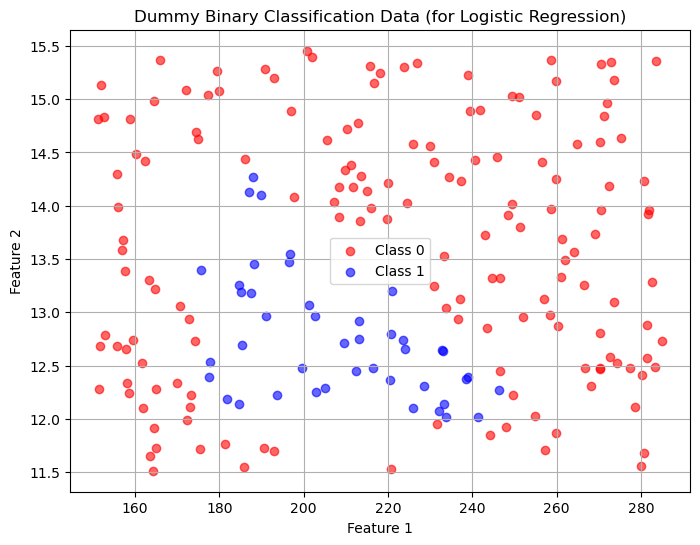

In [20]:
import numpy as np
from matplotlib import pyplot as plt

def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y)

X,y = load_coffee_data()
print(X.shape, y.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
#normal-data
normal_data=X[y==1]

#mean and standard-deviation
mu=np.mean(normal_data,axis=0)
std = np.std(normal_data, axis=0)

#probability
probability=np.prod((1/(np.sqrt(2*np.pi)*std)) * np.exp(-((X-mu)**2)/(2*(std**2))),axis=1)

best_epsilon=0.002
epsilon=np.percentile(probability,20)
best_F1=0
step_size=(max(probability)-min(probability))/1000
y_pred=[]


for epsilon in np.arange(min(probability),max(probability),step_size):
    
    F1=0
    predictions=~(prob<epsilon)
    
    
    tp = np.sum((predictions == 1) & (y == 1))
    fn = np.sum((predictions == 0) & (y == 1))
    fp = np.sum((predictions == 1) & (y == 0))
    tn = np.sum((predictions == 0) & (y == 0))

    #precision
    prec = tp / (tp + fp)
    #recall
    rec = tp / (tp + fn)
    #F1-score
    F1 = 2 * prec * rec / (prec + rec)

    if F1 > best_F1:
           best_F1 = F1
           best_epsilon = epsilon
           y_pred=predictions.copy()

accuracy=np.mean(y_pred==y)*100

In [22]:
best_epsilon

np.float64(0.002966781264568669)

In [23]:
best_F1

np.float64(0.8571428571428572)

In [24]:
accuracy

np.float64(94.0)

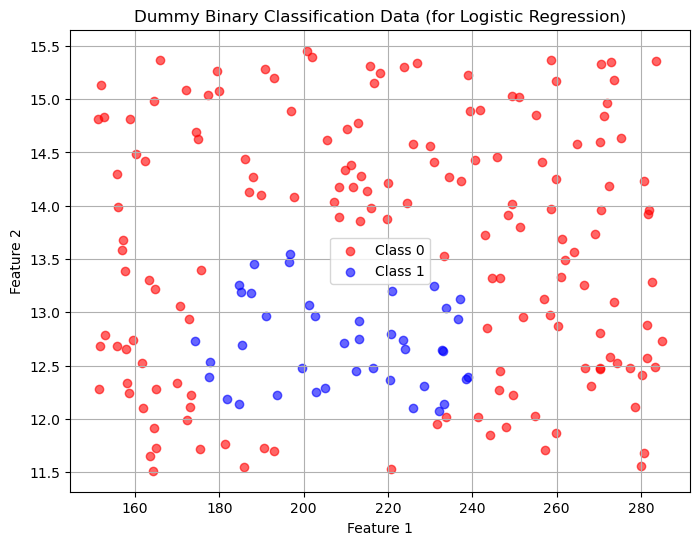

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y_pred.flatten() == 0][:, 0], X[y_pred.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y_pred.flatten() == 1][:, 0], X[y_pred.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()